In [20]:
from pydol.photometry.scripts.gloess import gloess
from pydol.photometry.scripts.catalog_filter import box
from pydol.photometry.scripts.cmdtools import gen_CMD, gen_CMD_ycut, gen_CMD_xcut, running_avg

from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
from astropy.visualization import simple_norm
from astropy.coordinates import angular_separation
from astropy.modeling import models, fitting
from astropy.stats import sigma_clipped_stats
from astropy.stats.biweight import biweight_location, biweight_midvariance,biweight_scale

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoLocator, AutoMinorLocator)
from matplotlib.colors import ListedColormap

import json

# **Data**

In [2]:
hdul = fits.open('../data/m51/data/stage3/F115W_i2d.fits')

In [3]:
f115w = hdul[1].data
f115w_wcs = WCS(hdul[1].header)

Set DATE-AVG to '2023-06-14T18:26:43.496' from MJD-AVG.
Set DATE-END to '2023-06-14T19:02:31.534' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -35.941881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1721165139.558 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


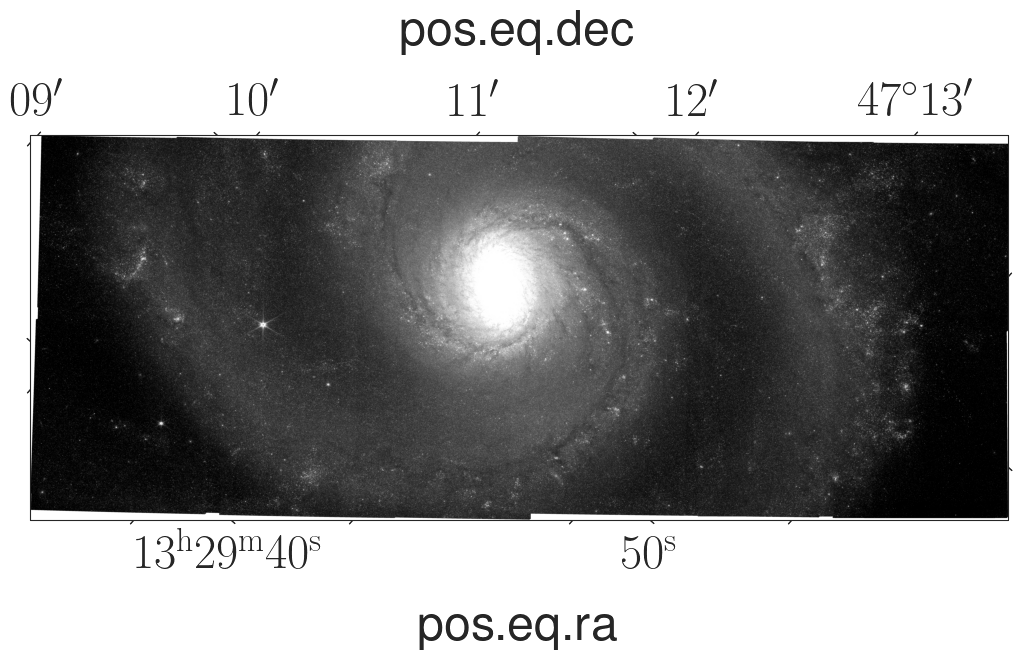

In [4]:
fig = plt.figure(figsize=(15,5))
ax = fig.add_subplot(projection=f115w_wcs)
norm = simple_norm(f115w, 'log', min_percent=10, max_percent=99, log_a=10)
ax.imshow(f115w, norm=norm, cmap='gray')

In [5]:
pixel_scale = f115w_wcs.wcs.cdelt[0]*3600

l = 24/pixel_scale
y = np.arange(0, f115w.shape[0] + l, l)
x = np.arange(0, f115w.shape[1] + l, l)

x_cen = 0.5*(x[:-1] + x[1:])
y_cen = 0.5*(y[:-1] + y[1:])


In [6]:
poss = []

x_offset = 0
y_offset = 0
for i in x_cen:
    for j in y_cen:
        poss.append([i-x_offset,j-y_offset])
        
poss = np.array(poss)

(0.0, 4520.0)

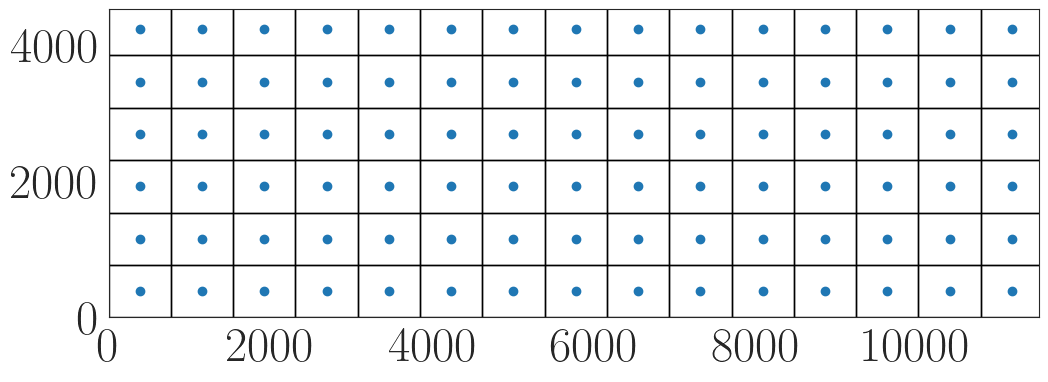

In [7]:
x = poss[:,0]
y = poss[:,1]
fig, ax = plt.subplots(figsize=(12,4))
ax.scatter(x,y)

for i,j in poss:
        ax.add_patch(plt.Rectangle((i-l/2, j-l/2), l,l, fill = False,
                              edgecolor='black', lw=1))

ax.set_xlim(0,f115w.shape[1])
ax.set_ylim(0,f115w.shape[0])

In [8]:
coords  = np.array(f115w_wcs.pixel_to_world_values(poss)).astype(np.float64)

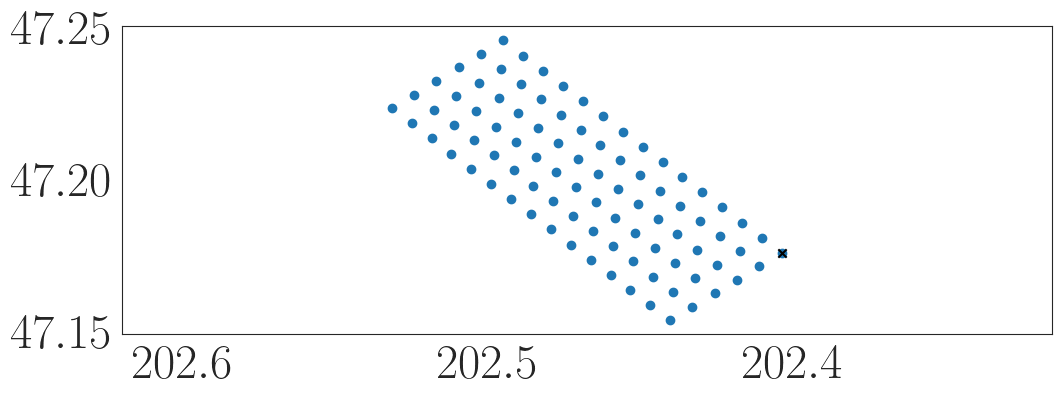

In [9]:
fig, ax = plt.subplots(figsize=(12,4))
angle =  131.67459
x = coords[:,0]
y = coords[:,1]
ax.scatter(x,y)

regions = {}
text = """# Region file format: DS9 version 4.1
global color=red dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
icrs\n"""
with open('regions_24_m51.reg', 'w') as f:
    f.writelines(text)
    for n,coord in enumerate(coords):
        i = coord[0]
        j = coord[1]
        regions[f'reg_{n}'] = {}
        regions[f'reg_{n}']['ra'] = i
        regions[f'reg_{n}']['dec'] = j
        f.writelines(f"""box({np.round(i,9)}, {np.round(j,9)}, {l*pixel_scale}", {l*pixel_scale}",{angle}) # text=""" + '{' + f'Reg {n}' + '}\n')
    
    ra_t = regions['reg_0']['ra']
    dec_t = regions['reg_0']['dec']
    
    ax.scatter([ra_t], [dec_t], marker='x', color='black')
    ax.invert_xaxis()
    ax.axis('equal')

In [10]:
with open('regions90_m51.json', 'w') as convert_file: 
     convert_file.write(json.dumps(regions))

# **Color-Magnitude Diagrams**

In [11]:
Av_dict = { 
            'f275w': 2.02499,
            'f336w': 1.67536,
            'f435w': 1.33879,
            'f555w': 1.03065,
            'f814w': 0.59696,
    
            'f090w': 0.583,
            'f115w': 0.419,
            'f150w': 0.287,
            'f200w': 0.195,
    
            'f438w': 1.34148,
            'f606w': 0.90941,
            'f814w': 0.59845
          }

with open('regions90_m51.json') as json_file:
    regions = json.load(json_file)

In [12]:
df_cmd_jwst = pd.read_csv("../data/isochrones_master/cmd_jwst.csv")

/part1/avinash/venv/jwst2/lib/python3.11/site-packages/pydol/photometry/scripts/cmdtools.py:441: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/part1/avinash/venv/jwst2/lib/python3.11/site-packages/pydol/photometry/scripts/cmdtools.py:441: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/part1/avinash/venv/jwst2/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/part1/avinash/venv/jwst2/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


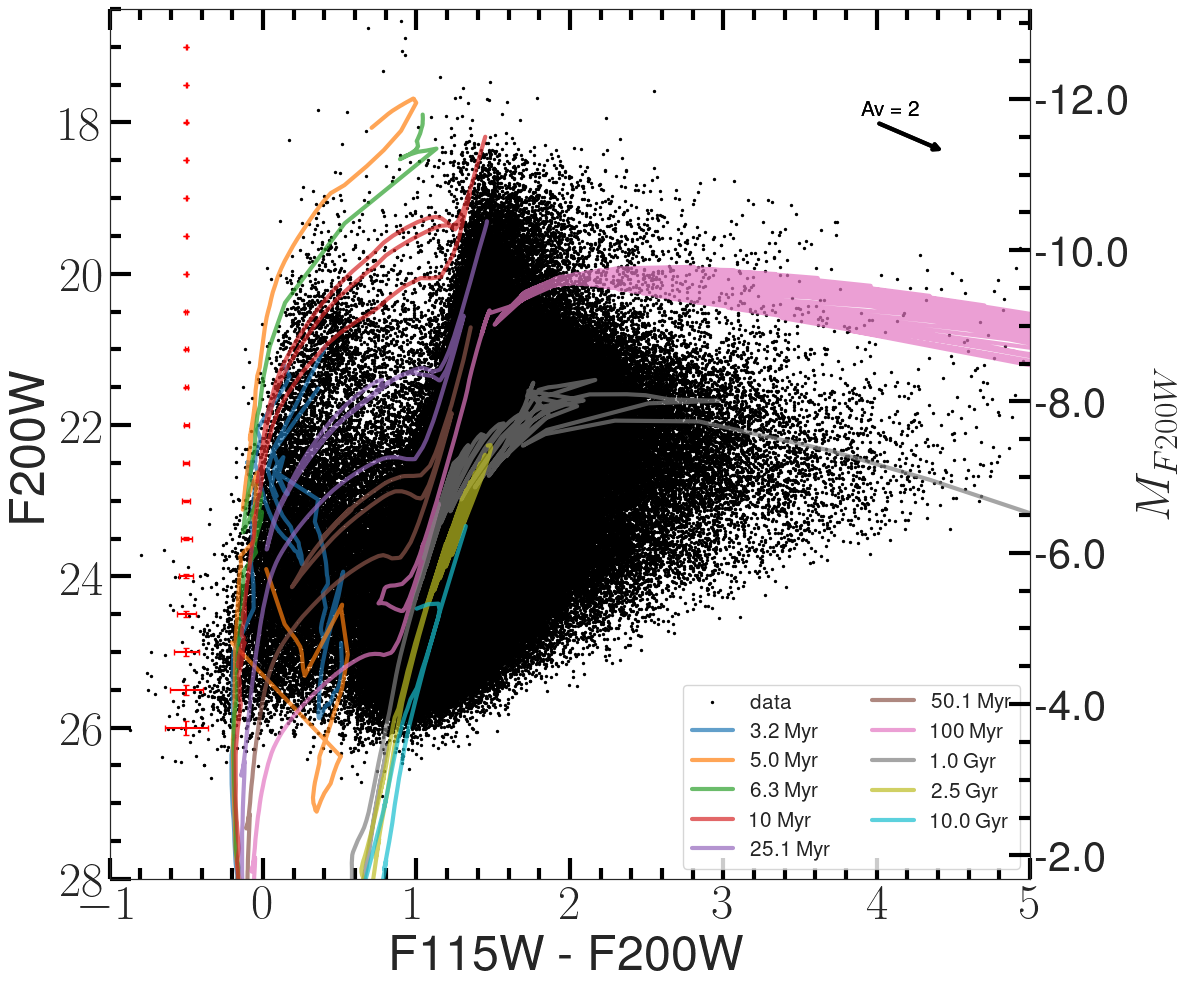

In [13]:
tab = Table.read('../data/m51/photometry/f115w_f150w_f200w_photometry.fits')

fig, ax = plt.subplots(figsize=(12,10))
ra_cen = 202.4696090 
dec_cen = 47.1951875

filters = {'filt1':'f115w',
           'filt2':'f200w',
           'filt3':'f200w'}

positions = {'ra_col' : 'ra',
             'dec_col': 'dec',
             'ra_cen' : ra_cen,
             'dec_cen': dec_cen}

region = {'r_in':0,
          'r_out': 2000,
          'spatial_filter': 'circle'}

extinction = {'Av'  : 0.095,
              'Av_x': 4,
              'Av_y': 18,
              'Av_' : 2}

axis_limits= {'xlims': [-1, 5], 
              'ylims': [16.5, 28]}

isochrone_params={'met': [0.02],
                  'label_min': 0,
                  'label_max': 10,
                  'ages': [6.5, 6.7, 6.8, 7,7.4,7.7, 8]}

error_settings = {'ref_xpos': -0.5,
                  'mag_err_lim':0.2}

plot_settings = {'s':2, 'legend.ncols':2, 'alpha':0.7, 'lw':3}


fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_jwst,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': False, 'skip_data': False},
                      fig=fig, ax=ax)

isochrone_params['ages'] = [9.0, 9.4, 10.]
isochrone_params['met'] = [0.002]

fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_jwst,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': True, 'skip_data': True},
                      fig=fig, ax=ax)
#fig.savefig('figures/m51_cmd.png', bbox_inches='tight')

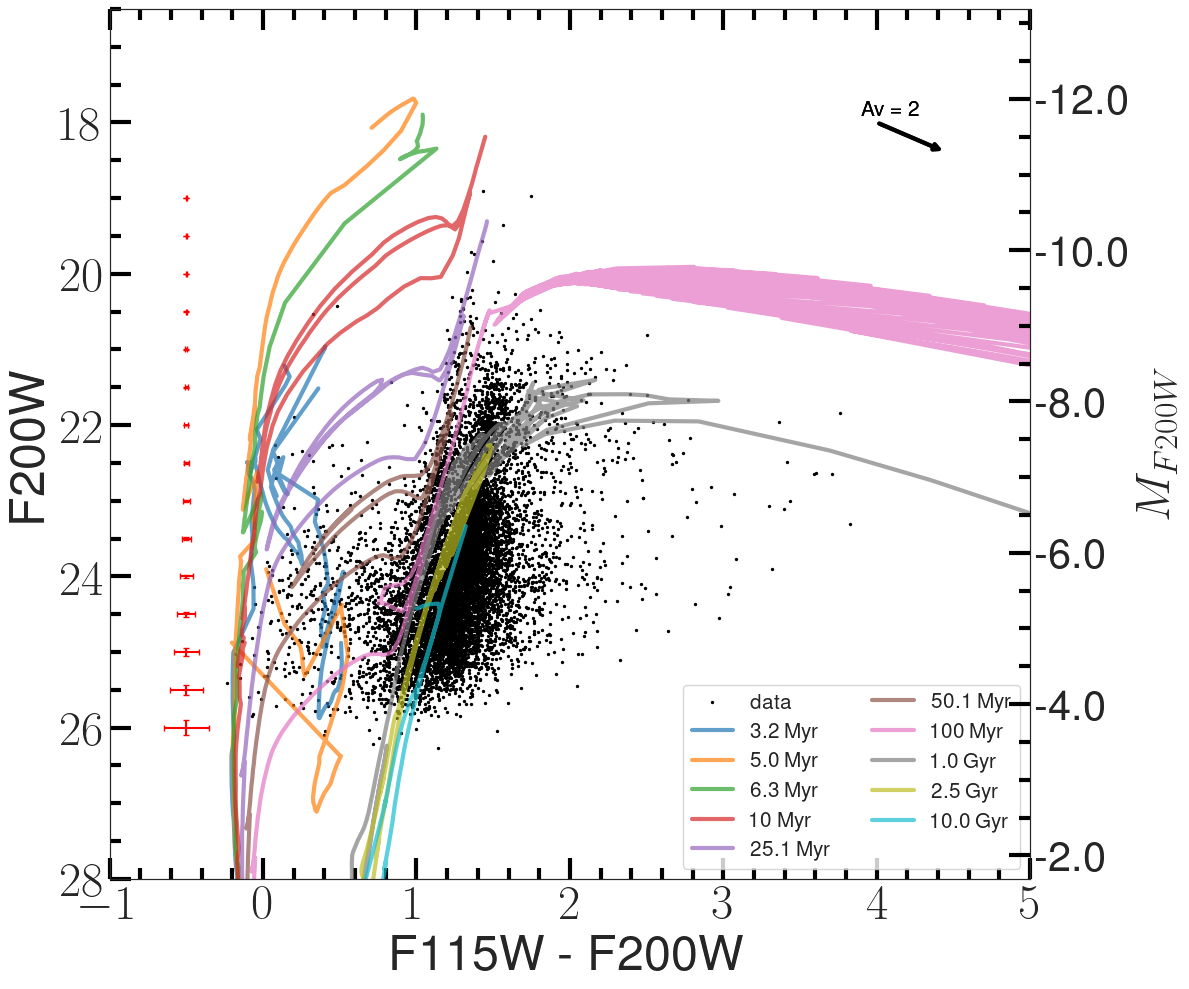

In [14]:
tab = Table.read('../data/m51/photometry/f115w_f150w_f200w_photometry.fits')

fig, ax = plt.subplots(figsize=(12,10))
ra_cen  = regions['reg_0']['ra']
dec_cen = regions['reg_0']['dec']

filters = {'filt1':'f115w',
           'filt2':'f200w',
           'filt3':'f200w'}

positions = {'ra_col': 'ra',
             'dec_col' : 'dec',
             'ra_cen': ra_cen,
             'dec_cen': dec_cen}

region = {'width_in'  : 0,
          'height_in' : 0,
          'width_out' : 24,
          'height_out': 24,
          'ang'       : 131.67459,
          'spatial_filter': 'box'}

extinction = {'Av'  : 0.095,
              'Av_x': 4,
              'Av_y': 18,
              'Av_' : 2}

axis_limits= {'xlims': [-1, 5], 
              'ylims': [16.5, 28]}

isochrone_params={'met': [0.02],
                  'label_min': 0,
                  'label_max': 10,
                  'ages': [6.5, 6.7, 6.8, 7,7.4,7.7, 8]}

error_settings = {'ref_xpos': -0.5,
                  'mag_err_lim':0.2}

plot_settings = {'s':2, 'legend.ncols':2, 'alpha':0.7, 'lw':3}


fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_jwst,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': False, 'skip_data': False},
                      fig=fig, ax=ax)

isochrone_params['ages'] = [9.0, 9.4, 10.]
isochrone_params['met'] = [0.002]

fig,ax, tab1 = gen_CMD(tab, 
                      df_cmd_jwst,
                      filters, 
                      positions,
                      region,
                      extinction,
                      29.67,
                      axis_limits,
                      isochrone_params,
                      plot_settings=plot_settings,
                      error_settings=error_settings,
                      other_settings={'ab_dist': True, 'skip_data': True},
                      fig=fig, ax=ax)
#fig.savefig('figures/ngc_628.png', bbox_inches='tight')

# **TRGB**

## **Magnitude**

/part1/avinash/venv/jwst2/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/part1/avinash/venv/jwst2/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_1925606/426439966.py:385: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


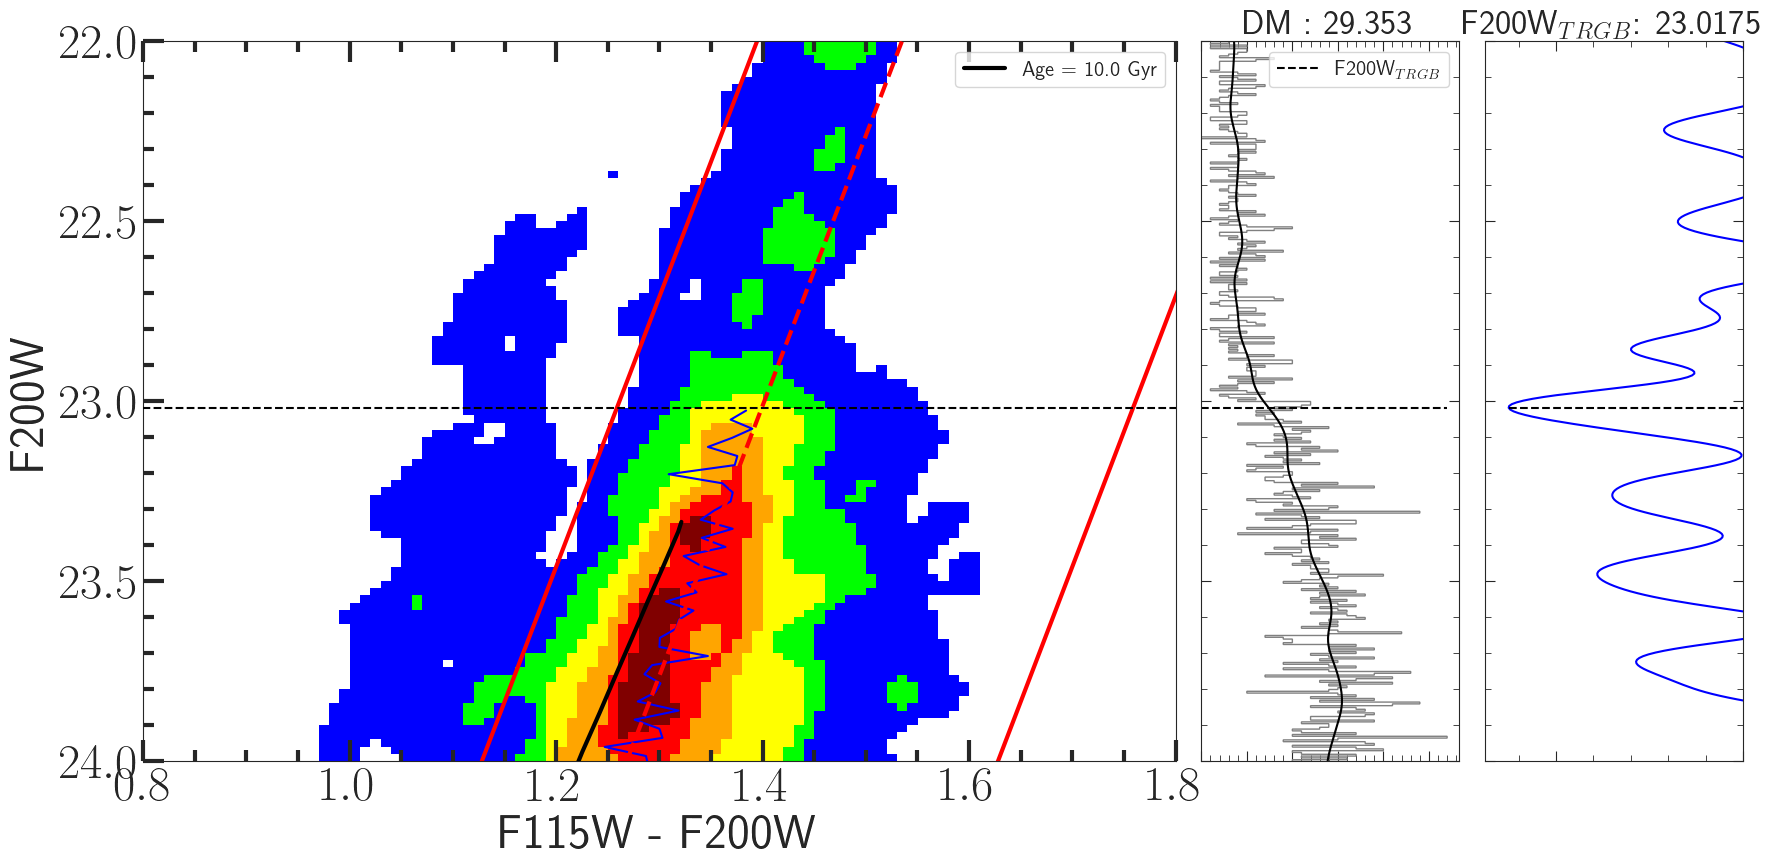

In [55]:
tab = Table.read('../data/m51/photometry/f115w_f150w_f200w_photometry.fits')

ra_cen  = regions['reg_0']['ra']
dec_cen = regions['reg_0']['dec']

filters = {'filt1':'f115w',
           'filt2':'f200w',
           'filt3':'f200w'}

positions = {'ra_col': 'ra',
             'dec_col' : 'dec',
             'ra_cen': ra_cen,
             'dec_cen': dec_cen}

region = {'width_in'  : 0,
          'height_in' : 0,
          'width_out' : 24,
          'height_out': 24,
          'ang'       : 131.67459,
          'spatial_filter': 'box'}

extinction = {'Av'  : 0.095,
              'Av_x': 3,
              'Av_y': 26,
              'Av_' : 2}

axis_limits= {'xlims': [0.8, 1.8], 
              'ylims': [22, 24]}

isochrone_params={'met'      : 0.002,
                  'label_min': 0,
                  'label_max': 3,
                  'ages'     : 10.0}

error_settings = {'ref_xpos': -0.5,
                  'mag_err_lim':0.2}

newcmp = ListedColormap(["#FFFFFF",  # Black
                        "#0000FF",  # Blue
                        "#00FF00",  # Green
                        "#FFFF00",  # Yellow
                        "#FFA500",  # Orange
                        "#FF0000",  # Red
                        "#800000"   # Dark Red
                                            ])
plot_settings = {'s':2, 'legend.ncols':2, 'alpha':0.7, 'lw':3,'cmap' : newcmp}

y_cut_settings = {'cmd_xlo' : 1.15,
                  'cmd_xhi' : 1.7,
                  'dx'      : 0.5,
                  
                  'fit_rgb' : True,
                  'rgb_yhi' : 25.5
                 }


kde_contours = {'gen_kde': True}
other_settings = {'ab_dist' :False}

fig = plt.figure(figsize=(20, 9))
gs = fig.add_gridspec(1, 3,  width_ratios=(4, 1,1),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)
ax =  fig.add_subplot(gs[0, 0])

fig, ax, dats, x_rgb_mid, y_rgb_mid, x_rgbn, params = gen_CMD_ycut(tab=tab,
                                                     df_iso=df_cmd_jwst,
                                                     distance_modulus=29.67,
                                                     filters=filters,
                                                     positions=positions,
                                                     region=region,
                                                     extinction=extinction,
                                                     axis_limits=axis_limits,
                                                     isochrone_params=isochrone_params,
                                                     error_settings=error_settings,
                                                     plot_settings=plot_settings,
                                                     y_cut_settings=y_cut_settings,
                                                     kde_contours=kde_contours,
                                                     other_settings=other_settings,
                                                     fig=fig,
                                                     ax=ax)

ax_hist = fig.add_subplot(gs[0, 1], sharey=ax)
ax_edge = fig.add_subplot(gs[0, 2], sharey=ax)

mag_lims = [22,24]
for dat in dats:
    x = dat[0]
    y = dat[1]

    bins = np.arange(19,28,0.005)
    yh,xh,_, = ax_hist.hist(y,bins, orientation='horizontal' , histtype='step', color='grey')
    xh = 0.5*(xh[1:] + xh[:-1])

    yf = gloess(xh,yh,0.05,1)
    ysob = np.convolve(yf,np.array([-1,0,1]), mode='same')

    ax_hist.plot(yf, xh, color='black')
    ax_edge.plot(ysob, xh,'b')

    c1 = (xh>=mag_lims[0]) & (xh<=mag_lims[1])
    m = xh[c1][ysob[c1]==ysob[c1].min()][0]

    ax_hist.tick_params(axis="y", labelleft=False)
    ax_edge.tick_params(axis="x", labelbottom=False)
    ax_edge.tick_params(axis="y", labelleft=False)

    ax_edge.set_title(f"{filters['filt2'].upper()}"+ '$_{TRGB}$' f': {np.round(m,5)}', fontsize=25)
    ax.plot([0,3],[m,m],'--k', zorder=201)
    ax_hist.plot([0,yh.max()],[m,m],'--k',label=f"{filters['filt2'].upper()}"+ '$_{TRGB}$')
    ax_hist.legend(fontsize=15)
    ax_hist.set_xticks([np.ceil(yh.max())],[np.ceil(yh.max())])
    ax_hist.tick_params(axis='both', labelsize=0)
    dismod = m - params[0]-params[1]
    ax_hist.set_title(f'DM : {np.round(dismod, 3)}', fontsize=25)
    ax_edge.plot([ysob.min(),ysob.max()],[m,m],'--k')
    ax_edge.set_xlim([ysob.min()*1.1,0])
    #ax_edge.invert_xaxis()

    for ax_ in [ax_hist, ax_edge]:
        ax_.xaxis.set_major_locator(AutoLocator())
        ax_.xaxis.set_minor_locator(AutoMinorLocator())

        ax_.yaxis.set_major_locator(AutoLocator())
        ax_.yaxis.set_minor_locator(AutoMinorLocator())

        ax_.tick_params(which='both', length=7,direction="in", bottom=True, top=True,left=True, right=True)
        ax_.tick_params(which='minor', length=4)

In [57]:
dats[0][0].shape

(7102,)

In [51]:
x_cut_settings['y_hi'] - x_cut_settings['y_lo']

0.0799999999999983

Fitting RGB stars


/part1/avinash/venv/jwst2/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/part1/avinash/venv/jwst2/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


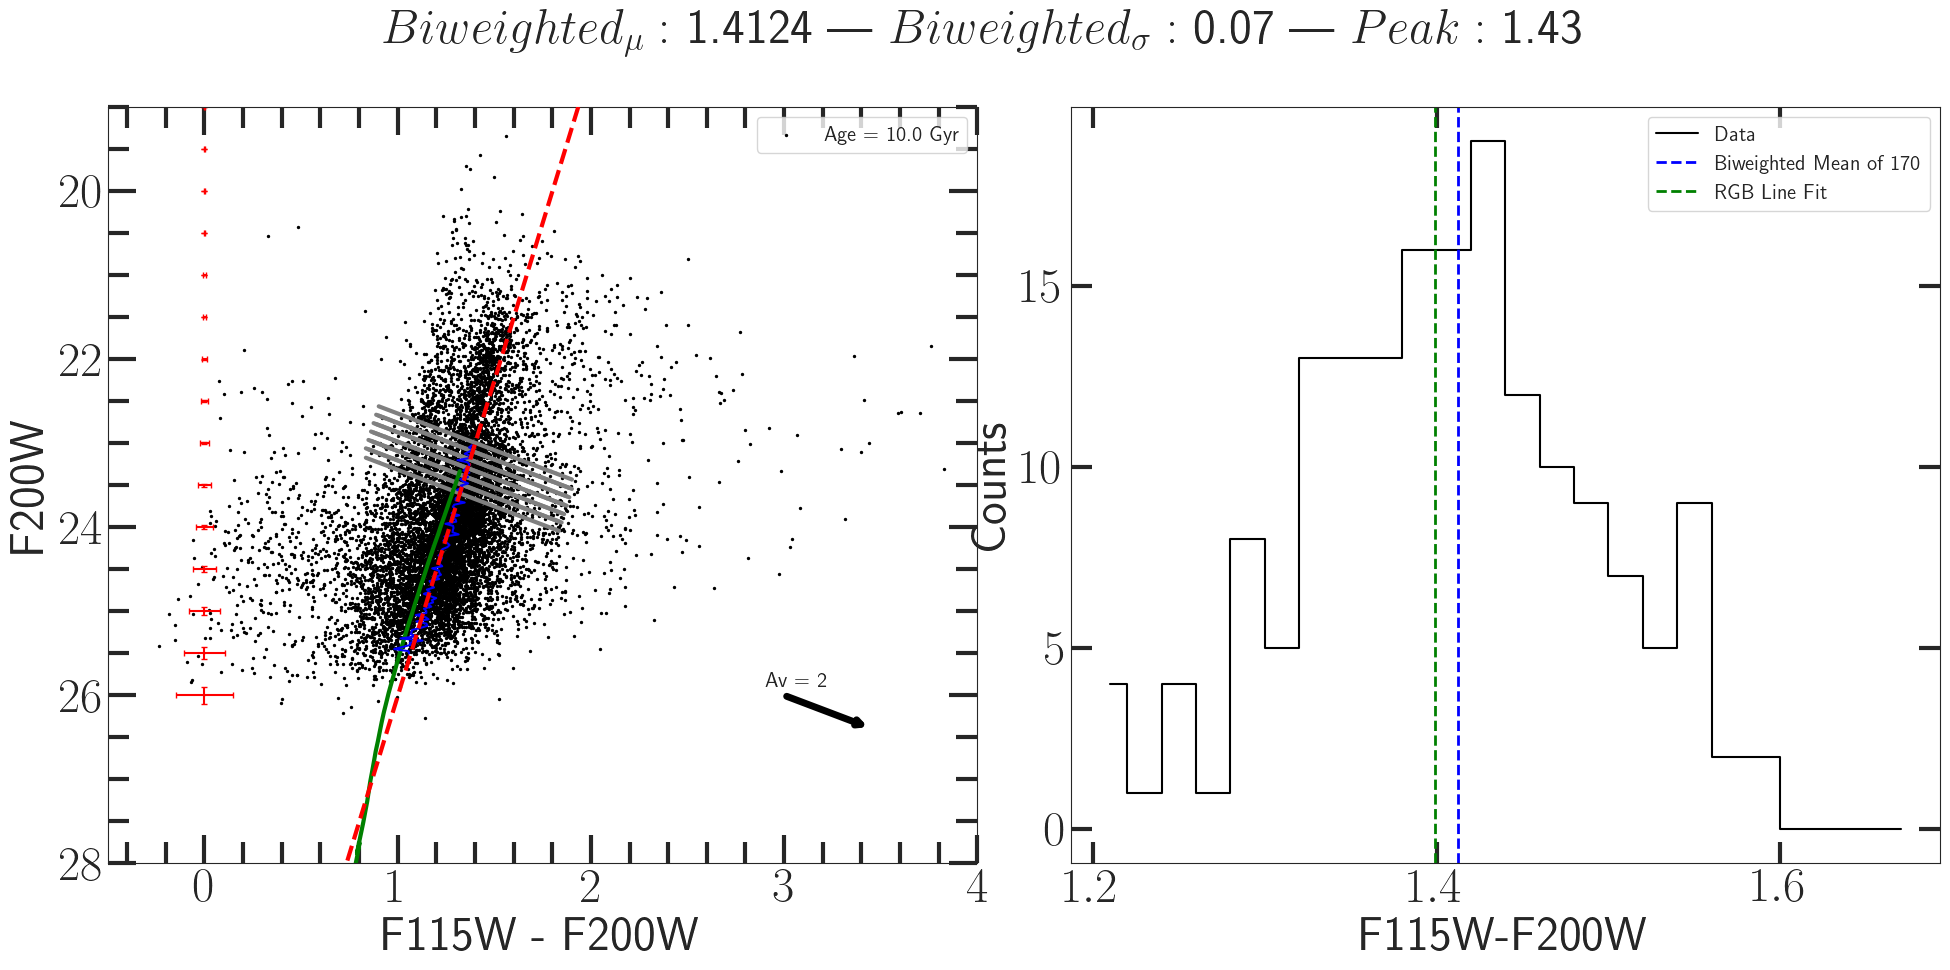

In [54]:

tab = Table.read('../data/m51/photometry/f115w_f150w_f200w_photometry.fits')

ra_cen  = regions['reg_0']['ra']
dec_cen = regions['reg_0']['dec']

filters = {'filt1':'f115w',
           'filt2':'f200w',
           'filt3':'f200w'}

positions = {'ra_col': 'ra',
             'dec_col' : 'dec',
             'ra_cen': ra_cen,
             'dec_cen': dec_cen}

region = {'width_in'  : 0,
          'height_in' : 0,
          'width_out' : 24,
          'height_out': 24,
          'ang'       : 131.67459,
          'spatial_filter': 'box'}

extinction = {'Av'  : 0.095,
              'Av_x': 3,
              'Av_y': 26,
              'Av_' : 2}

axis_limits= {'xlims': [-0.5, 4], 
              'ylims': [19, 28]}

isochrone_params={'met': 0.002,
                  'label_min': 0,
                  'label_max': 3,
                  'ages': 10.0}

error_settings = {'ref_xpos': 0,
                  'mag_err_lim':0.2}

plot_settings = {'s':2, 'legend.ncols':2, 'alpha':0.7, 'lw':3}

x_cut_settings = {'cmd_xlo' : 1.3,
                  'cmd_xhi' : 1.7,
                  'cmd_ylo' : 22,
                  'cmd_yhi' : 26,
                  'y_lo'    : m - 0.02,
                  'y_hi'    : m + 0.581 ,
                  'x_lo'    : 1.2,
                  'x_hi'    : 1.7,                  
                  'dy'      : 0.1,
                  'dx'      : 1,
                  
                  'fit_rgb' : True,
                  'fit_isochrone' : False,
                  'rgb_yhi' : 25.5,

                  
                  }

fig, ax = plt.subplots(1,2,figsize=(20, 9))

_, _, dats, x_val, y_val, y_bins, model_rgb= gen_CMD_xcut(tab=tab,
                                                     df_iso=df_cmd_jwst,
                                                     distance_modulus=29.67,
                                                     filters=filters,
                                                     positions=positions,
                                                     region=region,
                                                     extinction=extinction,
                                                     axis_limits=axis_limits,
                                                     isochrone_params=isochrone_params,
                                                     error_settings=error_settings,
                                                     plot_settings=plot_settings,
                                                     x_cut_settings=x_cut_settings,
                                                     fig=fig,
                                                     ax=ax[0])

ax[0].tick_params(which='both', length=20,direction="in", bottom=True, top=True,left=True, right=True)
ax[0].tick_params(which='minor', length=15)

dat = dats[0][0]
bins  = np.arange(x_cut_settings['x_lo'],x_cut_settings['x_hi'], 0.02)
y, x = np.histogram(dat, bins=bins)

max_bub = y.max()

x = 0.5*(x[1:] + x[:-1])

ax[1].step(x,y, where='mid', color='black')

mean, median, stddev= sigma_clipped_stats(dat, sigma=2, cenfunc=biweight_location, stdfunc=biweight_scale, maxiters=10)

p = x[y==y.max()][0]
x_p1 = mean
s_p1 = stddev

ax[1].axvline(x_p1, linestyle = '--', color='blue', lw=2)
ax[1].axvline(model_rgb(m), linestyle = '--', color='green', lw=2)

title = ''
title += r"$Biweighted_{\mu}:$ " + f"{np.round(x_p1,4)} | "
title += r'$Biweighted_{\sigma}:$ ' + f"{np.round(s_p1,4)}"
title += r' | $Peak :$' + f' {np.round(p,4)}\n'

ax[1].set_title(title, fontsize=35,x=-0.1)
ax[1].set_ylabel('Counts', fontsize=35)

ax[1].set_xlabel(f"{filters['filt1'].upper()}-{filters['filt2'].upper()}")

init = models.Gaussian1D()
fit = fitting.LevMarLSQFitter()
ridge = []
ridge_std = []
for dat in dats:
    data = dat[0]
    bins = np.arange(data.min(), data.max(), 0.02)
    y,x = np.histogram(data,bins=bins)
    x = 0.5*(x[1:] + x[:-1])

    model = fit(init,x,y)
    ridge.append(model.mean.value)
    ridge_std.append(model.stddev.value)

init = models.Linear1D()
fit = fitting.LinearLSQFitter()
model_ridge = fit(init, y_val ,ridge)

#ax[1].axvline(model_ridge(m), linestyle = '--', color='orange', lw=2)

ax[1].legend(['Data',f'Biweighted Mean of {len(dats[0][0])}','RGB Line Fit','Ridge Fit'], fontsize=15)
#fig.savefig(f"TRGBv2/reg_10_color.png")
ax[1].tick_params(which='both', length=15,direction="in", bottom=True, top=True,left=True, right=True,width=3)
ax[1].tick_params(which='minor', length=8,width=3)

In [49]:
y_val

array([], dtype=float64)